## Simulated Single-Population Logistic Growth Curves

Replicating the logistic model from the paper: $\frac{dp}{dt} = \mu(1-p)p$, where $p$ is relative abundance and $\mu$ is the specific growth rate.

- **N = 1000** curves, **D = 100** points each
- $\mu \sim \text{Uniform}(0.2, 1.0)$, $p_0 = 0.01$, $t \in [0, 50]$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
np.random.seed(42)

N = 1000   # number of curves
D = 100    # points per curve (dimension of input)
p0 = 0.01  # initial relative abundance

t = np.linspace(0, 50, D)

# mu >= 0.2 ensures all curves reach p≈0.99 within t=50
mu = np.random.uniform(0.2, 1.0, N)

# Analytical solution to dp/dt = mu*(1-p)*p with p(0) = p0:
# p(t) = 1 / (1 + (1/p0 - 1) * exp(-mu * t))
curves = 1.0 / (1.0 + (1.0 / p0 - 1.0) * np.exp(-mu[:, None] * t[None, :]))

# Global normalisation (matching paper): scale entire dataset to [0, 1]
curves = (curves - curves.min()) / (curves.max() - curves.min())

print(f"curves shape: {curves.shape}")
print(f"mu range:     [{mu.min():.3f}, {mu.max():.3f}]")
print(f"value range:  [{curves.min():.3f}, {curves.max():.3f}]")

curves shape: (1000, 100)
mu range:     [0.204, 1.000]
value range:  [0.000, 1.000]


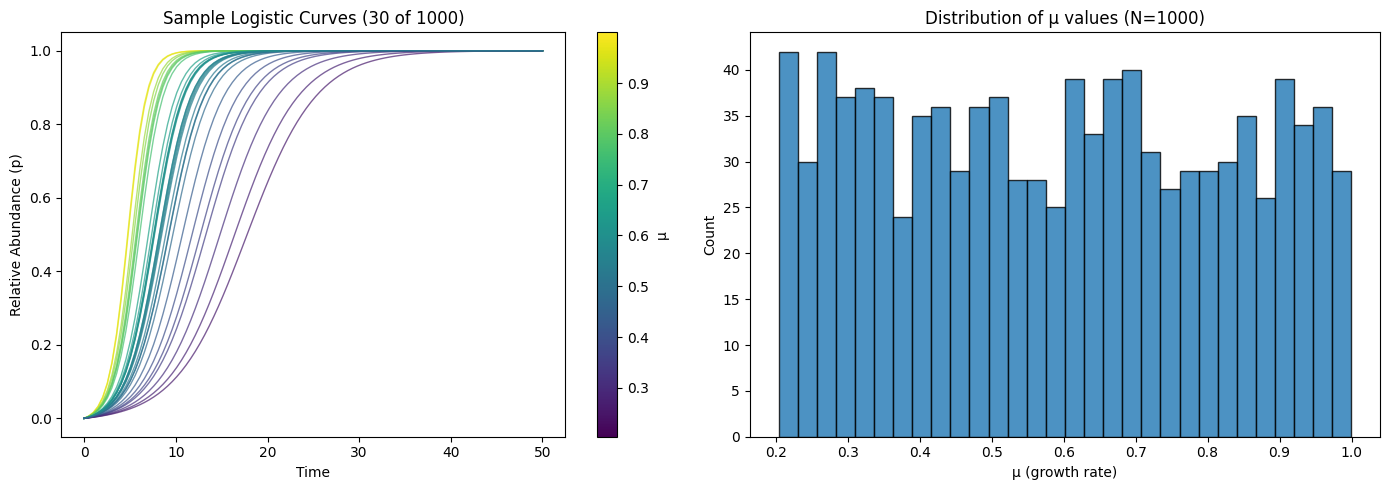

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample curves coloured by mu
sample_idx = np.linspace(0, N - 1, 30, dtype=int)
sc = axes[0].scatter([], [], c=[], cmap='viridis')  # dummy for colorbar
for i in sample_idx:
    axes[0].plot(t, curves[i], color=plt.cm.viridis((mu[i] - mu.min()) / (mu.max() - mu.min())), alpha=0.7, lw=1)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(mu.min(), mu.max()))
plt.colorbar(sm, ax=axes[0], label='μ')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Relative Abundance (p)')
axes[0].set_title('Sample Logistic Curves (30 of 1000)')

# Right: histogram of mu values
axes[1].hist(mu, bins=30, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('μ (growth rate)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of μ values (N=1000)')

plt.tight_layout()
plt.show()

## Autoencoder with E = 2

Asymmetric autoencoder: dilated causal convolutional encoder compresses D=100 → E=2, MLP decoder reconstructs E=2 → D=100.  
Loss: total square reconstruction error $\sum_i^N \|x_i - x'_i\|^2$.  
The paper expects the 2D embeddings to fall along a single line (≈ y = x).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import torch.nn.functional as F

torch.manual_seed(10)


class CausalConv1d(nn.Module):
    """1D convolution that only attends to past time points."""
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation)

    def forward(self, x):
        x = F.pad(x, (self.pad, 0))  # pad left only — causal
        return self.conv(x)


class DilatedCausalConvEncoder(nn.Module):
    """
    Stacks causal conv layers with doubling dilation [1,2,4,...,64].
    With kernel_size=2 and 7 layers the receptive field reaches 128 > D=100,
    so the last time step integrates the full input sequence.
    """
    def __init__(self, D=100, E=2, n_channels=32, kernel_size=2):
        super().__init__()
        dilations = [1, 2, 4, 8, 16, 32, 64]

        layers = []
        in_ch = 1
        for d in dilations:
            layers.append(CausalConv1d(in_ch, n_channels, kernel_size, dilation=d))
            layers.append(nn.ReLU())
            in_ch = n_channels

        self.conv_layers = nn.Sequential(*layers)
        self.fc = nn.Linear(n_channels, E)

    def forward(self, x):
        x = x.unsqueeze(1)       # (batch, 1, D)
        x = self.conv_layers(x)  # (batch, n_channels, D)
        x = x[:, :, -1]          # last time step has full receptive field
        return self.fc(x)        # (batch, E)


class Decoder(nn.Module):
    def __init__(self, E=2, D=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(E, 32),
            nn.ReLU(),
            nn.Linear(32, D),
            nn.Sigmoid(),
        )

    def forward(self, z):
        return self.net(z)


class Autoencoder(nn.Module):
    def __init__(self, D=100, E=2):
        super().__init__()
        self.encoder = DilatedCausalConvEncoder(D, E)
        self.decoder = Decoder(E, D)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


model = Autoencoder(D=100, E=2).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Autoencoder(
  (encoder): DilatedCausalConvEncoder(
    (conv_layers): Sequential(
      (0): CausalConv1d(
        (conv): Conv1d(1, 32, kernel_size=(2,), stride=(1,))
      )
      (1): ReLU()
      (2): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(2,))
      )
      (3): ReLU()
      (4): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(4,))
      )
      (5): ReLU()
      (6): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(8,))
      )
      (7): ReLU()
      (8): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(16,))
      )
      (9): ReLU()
      (10): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(32,))
      )
      (11): ReLU()
      (12): CausalConv1d(
        (conv): Conv1d(32, 32, kernel_size=(2,), stride=(1,), dilation=(64,))
      )
      (13): ReLU()
    )
    (fc): Linear(in_feat

In [ ]:
X = torch.tensor(curves, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='sum')  # total square error, matching the paper

epochs = 500
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    for (batch,) in loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        loss = criterion(recon, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:>4}/{epochs}  Total sq. error: {total_loss:.4f}")

print("Training complete.")

Epoch  100/500  Total sq. error: 56.0145
Epoch  200/500  Total sq. error: 1.5958
Epoch  300/500  Total sq. error: 0.5206
Epoch  400/500  Total sq. error: 0.1631
Epoch  500/500  Total sq. error: 0.2183
Training complete.


Variance explained — PC1: 99.8%  PC2: 0.2%


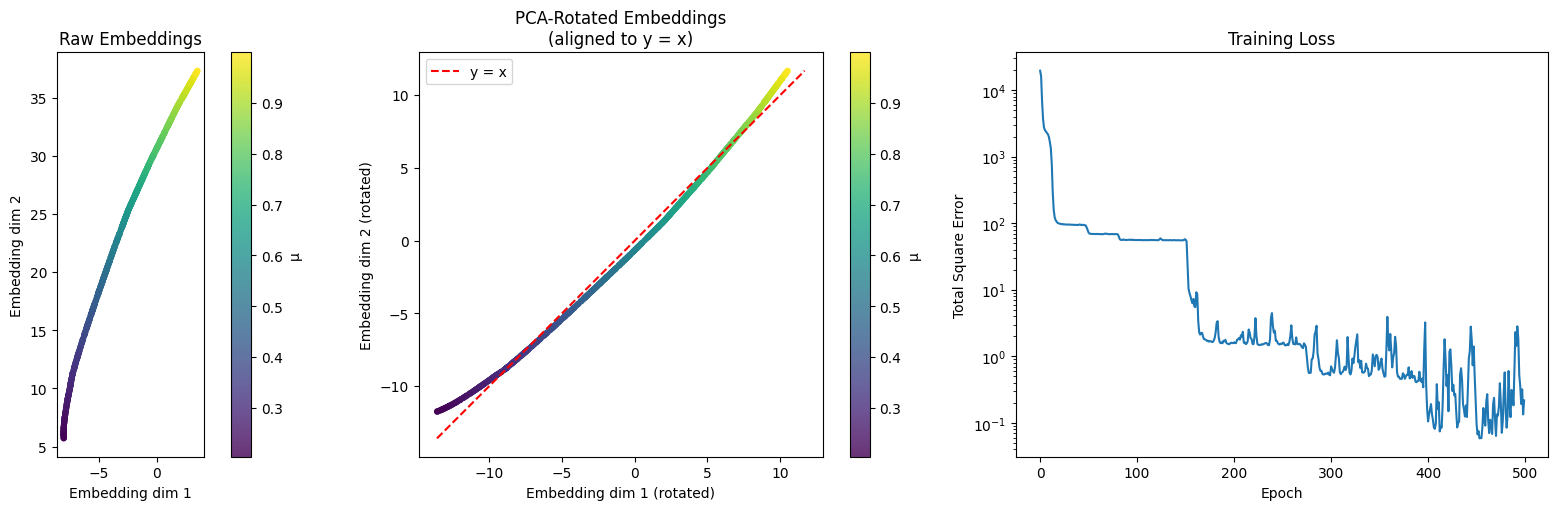

In [ ]:
from sklearn.decomposition import PCA

model.eval()
with torch.no_grad():
    _, embeddings = model(X.to(device))
    embeddings = embeddings.cpu().numpy()

# PCA-rotate so PC1 is horizontal, then rotate 45° to align with y=x
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)
explained = pca.explained_variance_ratio_
print(f"Variance explained — PC1: {explained[0]:.1%}  PC2: {explained[1]:.1%}")

theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
embeddings_rot = embeddings_pca @ R.T

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: raw embeddings
sc = axes[0].scatter(embeddings[:, 0], embeddings[:, 1], c=mu, cmap='viridis', s=12, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label='μ')
axes[0].set_xlabel('Embedding dim 1')
axes[0].set_ylabel('Embedding dim 2')
axes[0].set_title('Raw Embeddings')
axes[0].set_aspect('equal', 'box')

# Middle: PCA-rotated + 45° (aligned to y=x)
sc2 = axes[1].scatter(embeddings_rot[:, 0], embeddings_rot[:, 1], c=mu, cmap='viridis', s=12, alpha=0.8)
plt.colorbar(sc2, ax=axes[1], label='μ')
lims = [embeddings_rot.min(), embeddings_rot.max()]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='y = x')
axes[1].set_xlabel('Embedding dim 1 (rotated)')
axes[1].set_ylabel('Embedding dim 2 (rotated)')
axes[1].set_title('PCA-Rotated Embeddings\n(aligned to y = x)')
axes[1].set_aspect('equal', 'box')
axes[1].legend()

# Right: training loss
axes[2].plot(train_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Total Square Error')
axes[2].set_title('Training Loss')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## Microbial Community Growth Curves (gLV Model)

Simulating five-member communities using the generalized Lotka-Volterra (gLV) model:

$$\frac{dp_i}{dt} = p_i \left( r_i + \sum_j A_{ij} p_j \right)$$

where $p_i$ is the abundance of species $i$, $r_i$ is its intrinsic growth rate, and $A_{ij}$ encodes inter-species interactions.

- **1900 community simulations × 5 species = 9500 growth curves**, **D = 100** points each
- Random $r_i \sim \text{Uniform}(0.5, 2.0)$, self-competition $A_{ii} \sim \text{Uniform}(-1.0, -0.5)$, interactions $A_{ij} \sim \text{Uniform}(-0.5, 0.5)$

In [ ]:
np.random.seed(40)

N_communities = 1900
n_species = 5
D_glv = 100
t_glv = np.linspace(0, 20, D_glv)

# Random parameters for all communities at once: (N_communities, n_species)
r_batch = np.random.uniform(0.5, 2.0, (N_communities, n_species))
A_batch = np.random.uniform(-0.5, 0.5, (N_communities, n_species, n_species))
np.einsum('nii->ni', A_batch)[:] = np.random.uniform(-1.0, -0.5, (N_communities, n_species))  # self-competition
p0_batch = np.random.uniform(0.01, 0.1, (N_communities, n_species))

def gLV_rhs(p, r, A):
    """Batch gLV RHS. p, r: (N, S), A: (N, S, S)"""
    return p * (r + np.einsum('nij,nj->ni', A, p))

# Vectorised RK4 over all communities simultaneously
trajectories = np.zeros((N_communities, n_species, D_glv))
trajectories[:, :, 0] = p0_batch
p = p0_batch.copy()

for i in range(1, D_glv):
    dt = t_glv[i] - t_glv[i - 1]
    k1 = gLV_rhs(p,                  r_batch, A_batch)
    k2 = gLV_rhs(p + 0.5 * dt * k1, r_batch, A_batch)
    k3 = gLV_rhs(p + 0.5 * dt * k2, r_batch, A_batch)
    k4 = gLV_rhs(p + dt * k3,        r_batch, A_batch)
    p = p + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
    p = np.clip(p, 0, None)  # abundances can't go negative
    trajectories[:, :, i] = p

# Reshape to 9500 individual species growth curves, each of length D=100
glv_curves = trajectories.reshape(N_communities * n_species, D_glv)
print(f"glv_curves shape: {glv_curves.shape}")  # (9500, 100)

glv_curves shape: (9500, 100)


/tmp/ipykernel_4973/4276435143.py:16: RuntimeWarning: overflow encountered in multiply
  return p * (r + np.einsum('nij,nj->ni', A, p))
/tmp/ipykernel_4973/4276435143.py:16: RuntimeWarning: invalid value encountered in multiply
  return p * (r + np.einsum('nij,nj->ni', A, p))


In [ ]:
# Remove any blown-up simulations (NaN or inf)
valid_mask = np.all(np.isfinite(glv_curves), axis=1)
glv_curves = glv_curves[valid_mask]
print(f"Kept {glv_curves.shape[0]} / {valid_mask.shape[0]} curves after removing non-finite values")

# Per-curve min-max normalisation to [0, 1]
curve_min = glv_curves.min(axis=1, keepdims=True)
curve_max = glv_curves.max(axis=1, keepdims=True)
glv_curves_norm = (glv_curves - curve_min) / (curve_max - curve_min + 1e-8)

print(f"Normalised curves shape: {glv_curves_norm.shape}")
print(f"Value range: [{glv_curves_norm.min():.3f}, {glv_curves_norm.max():.3f}]")

Kept 9485 / 9500 curves after removing non-finite values
Normalised curves shape: (9485, 100)
Value range: [0.000, 1.000]


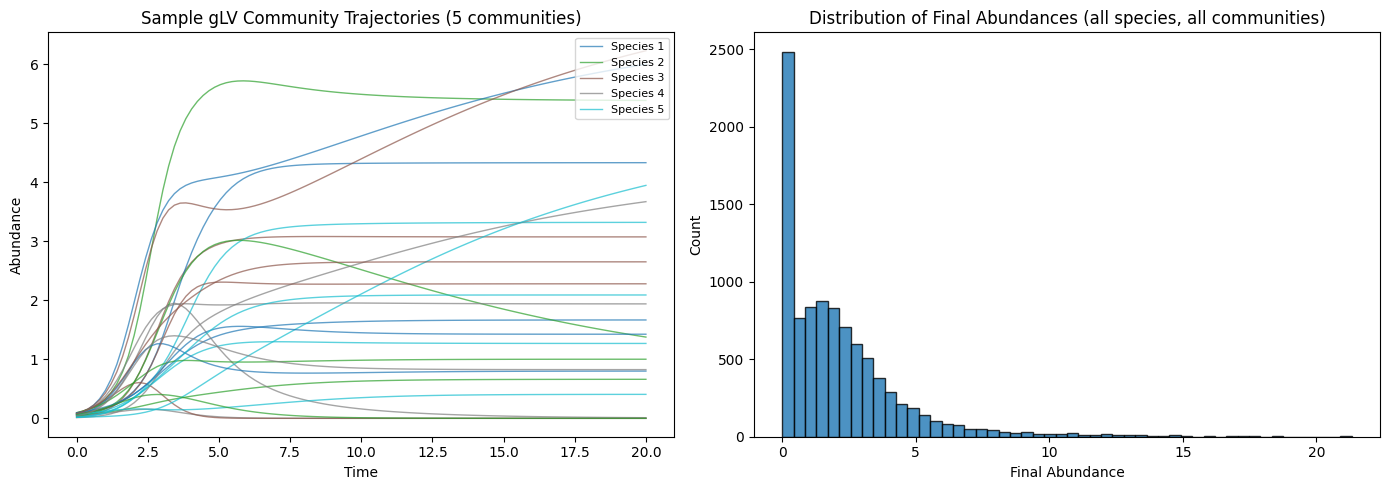

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: sample species trajectories from a few communities
colors = plt.cm.tab10(np.linspace(0, 1, n_species))
for c in range(5):  # 5 sample communities
    for s in range(n_species):
        axes[0].plot(t_glv, trajectories[c, s, :], color=colors[s],
                     alpha=0.7, lw=1, label=f'Species {s+1}' if c == 0 else '')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Abundance')
axes[0].set_title('Sample gLV Community Trajectories (5 communities)')
axes[0].legend(loc='upper right', fontsize=8)

# Right: distribution of final abundances across all simulations
final_abundances = trajectories[:, :, -1].flatten()
axes[1].hist(final_abundances, bins=50, edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Final Abundance')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Final Abundances (all species, all communities)')

plt.tight_layout()
plt.show()

## Autoencoder on gLV Community Curves (E = 2)

Training the same dilated causal CNN autoencoder on the 9500 gLV community growth curves.  
The paper expects embeddings with E = 2 to spread in **multiple directions** in latent space (unlike the single line for the logistic case), reflecting the higher-dimensional structure of the underlying system.

In [ ]:
torch.manual_seed(42)

model_glv = Autoencoder(D=100, E=2).to(device)

X_glv = torch.tensor(glv_curves_norm, dtype=torch.float32)
dataset_glv = TensorDataset(X_glv)
loader_glv = DataLoader(dataset_glv, batch_size=64, shuffle=True)

optimizer_glv = torch.optim.Adam(model_glv.parameters(), lr=1e-3)
criterion_glv = nn.MSELoss(reduction='sum')

epochs_glv = 500
train_losses_glv = []

for epoch in range(epochs_glv):
    model_glv.train()
    total_loss = 0.0
    for (batch,) in loader_glv:
        batch = batch.to(device)
        recon, _ = model_glv(batch)
        loss = criterion_glv(recon, batch)
        optimizer_glv.zero_grad()
        loss.backward()
        optimizer_glv.step()
        total_loss += loss.item()
    train_losses_glv.append(total_loss)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:>4}/{epochs_glv}  Total sq. error: {total_loss:.4f}")

print("Training complete.")

Epoch  100/500  Total sq. error: 1960.3693
Epoch  200/500  Total sq. error: 1715.4765
Epoch  300/500  Total sq. error: 1536.1919
Epoch  400/500  Total sq. error: 1857.6718
Epoch  500/500  Total sq. error: 1405.2156
Training complete.


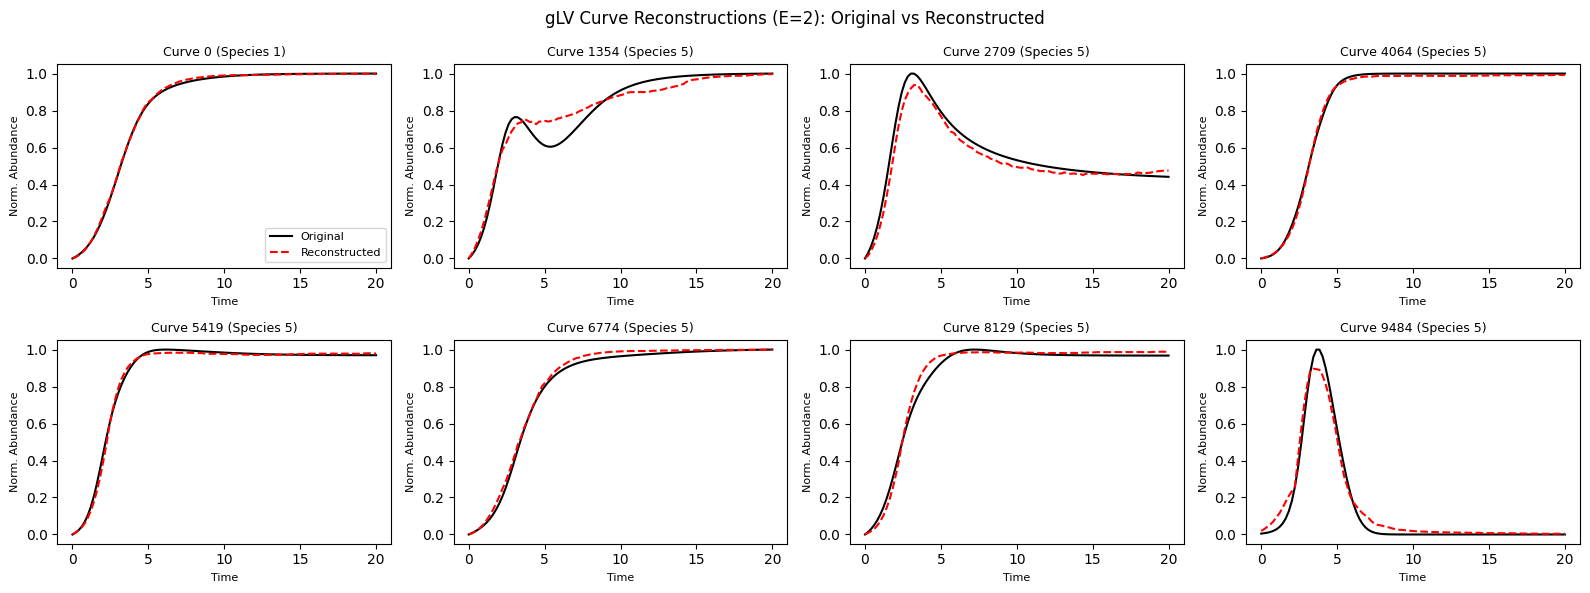

Mean absolute error (E=2): 0.0212  (2.1%)


In [ ]:
model_glv.eval()
with torch.no_grad():
    recon_glv = model_glv(X_glv.to(device))[0].cpu().numpy()

n_samples = 8
sample_idx = np.linspace(0, n_valid - 1, n_samples, dtype=int)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for plot_i, curve_i in enumerate(sample_idx):
    axes[plot_i].plot(t_glv, glv_curves_norm[curve_i], 'k-', lw=1.5, label='Original')
    axes[plot_i].plot(t_glv, recon_glv[curve_i], 'r--', lw=1.5, label='Reconstructed')
    species = curve_i % n_species
    axes[plot_i].set_title(f'Curve {curve_i} (Species {species + 1})', fontsize=9)
    axes[plot_i].set_xlabel('Time', fontsize=8)
    axes[plot_i].set_ylabel('Norm. Abundance', fontsize=8)
    if plot_i == 0:
        axes[plot_i].legend(fontsize=8)

plt.suptitle('gLV Curve Reconstructions (E=2): Original vs Reconstructed', fontsize=12)
plt.tight_layout()
plt.show()

# Summary MAE
mae = np.mean(np.abs(glv_curves_norm - recon_glv))
print(f"Mean absolute error (E=2): {mae:.4f}  ({mae*100:.1f}%)")

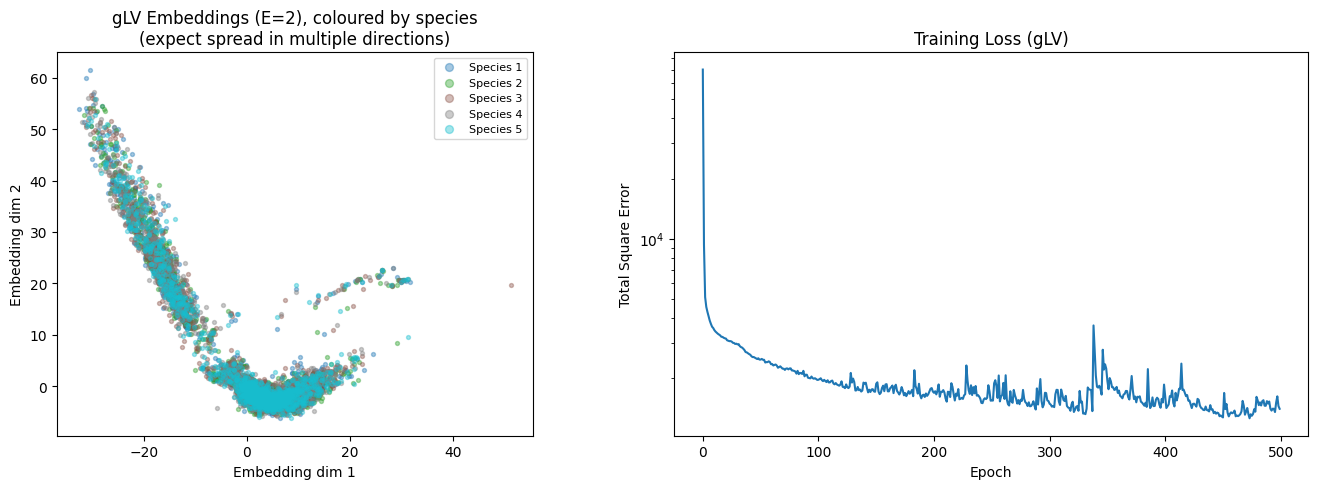

In [ ]:
model_glv.eval()
with torch.no_grad():
    _, embeddings_glv = model_glv(X_glv.to(device))
    embeddings_glv = embeddings_glv.cpu().numpy()

# Species index for each curve (0-4 repeating), trimmed to match valid curves
n_valid = glv_curves_norm.shape[0]
species_idx = np.tile(np.arange(n_species), N_communities)[:n_valid]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: embeddings coloured by species
colors = plt.cm.tab10(np.linspace(0, 1, n_species))
for s in range(n_species):
    mask = species_idx == s
    axes[0].scatter(embeddings_glv[mask, 0], embeddings_glv[mask, 1],
                    color=colors[s], s=8, alpha=0.4, label=f'Species {s+1}')
axes[0].set_xlabel('Embedding dim 1')
axes[0].set_ylabel('Embedding dim 2')
axes[0].set_title('gLV Embeddings (E=2), coloured by species\n(expect spread in multiple directions)')
axes[0].legend(markerscale=2, fontsize=8)
axes[0].set_aspect('equal', 'box')

# Right: training loss
axes[1].plot(train_losses_glv)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Total Square Error')
axes[1].set_title('Training Loss (gLV)')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()